In [1]:
# Setup imports and initial dataset load
import pandas as pd
import matplotlib.pyplot as plt

csv_df = pd.read_csv('public2024.csv')
print("Loaded public2024.csv with", csv_df.shape, "rows/cols")


Loaded public2024.csv with (12295, 751) rows/cols


C:\Users\barto\AppData\Local\Temp\ipykernel_12004\3411277954.py:5: DtypeWarning: Columns (0: L0C, 1: CG1A, 2: CG9, 3: D41_b, 4: GE1C, 5: GE1E_a, 6: GE1E_b, 7: GE1E_c, 8: GE1E_d, 9: GE1E_e, 10: GH12A, 11: R5C_a, 12: R5C_b, 13: R5C_c, 14: R5C_d, 15: BK48, 16: BK50, 17: BK51, 18: BK52_a, 19: BK52_b, 20: BK52_c, 21: BK52_d, 22: BK52_e, 23: BK52_f, 24: BK52_g, 25: BK52_h, 26: A8_b, 27: A8_c, 28: A8_d, 29: A8_e, 30: SL4, 31: SL13, 32: K14_a, 33: K14_b, 34: K15_a, 35: K15_b, 36: K15_c, 37: K15_d, 38: K15_e, 39: INF3_g, 40: ppfs0001, 41: ppfs0596, 42: ppfs1482, 43: pphi0001) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_df = pd.read_csv('public2024.csv')


BNPL1                                          No  Yes
educ_4cat                                             
Bachelor's degree or more                    4737  545
High school degree or GED                    2004  316
Less than a high school degree                466   92
Some college/technical or associates degree  3418  717
BNPL1                                  No        Yes
educ_4cat                                           
Bachelor's degree or more       89.681939  10.318061
High school degree or GED       86.379310  13.620690
Less than a high school degree  83.512545  16.487455
Associates or Dropouts          82.660218  17.339782


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\3592664955.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,


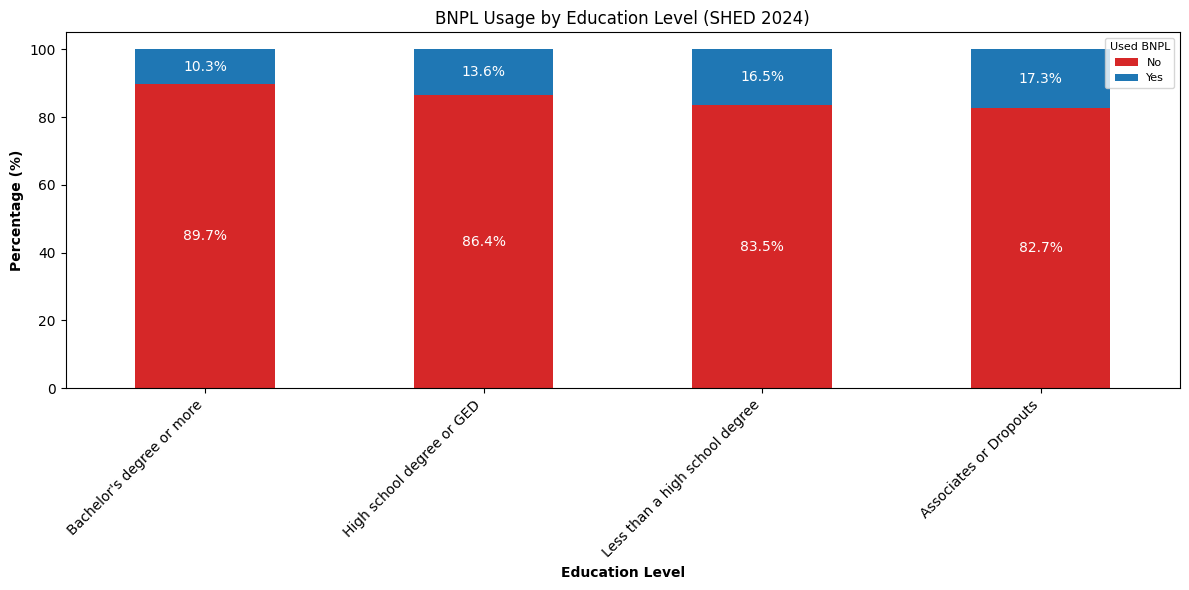

In [18]:
# calculate usage rates by education category

if 'csv_df' not in globals():
    csv_df = pd.read_csv('public2024.csv')
    print("Loaded public2024.csv with", csv_df.shape, "rows/cols")

group = csv_df.groupby(['educ_4cat','BNPL1']).size().unstack(fill_value=0)
# compute percentages within each education
grp_pct = group.div(group.sum(axis=1), axis=0) * 100

# rename index for cleaner labels
grp_pct.index = grp_pct.index.str.replace('Some college/technical or associates degree', 'Associates or Dropouts')

print(group)
print(grp_pct)

grp_pct.plot(kind='bar', stacked=True, figsize=(12,6), color=['#d62728','#1f77b4'])
plt.title('BNPL Usage by Education Level (SHED 2024)')
plt.ylabel('Percentage (%)', fontweight='bold')
plt.xlabel('Education Level', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Used BNPL', loc='upper right', fontsize=8, title_fontsize=8)

# add labels
for i, edu in enumerate(grp_pct.index):
    for j, val in enumerate(grp_pct.loc[edu]):
        plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,
                 f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('bnpl_by_education.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# create a tidy dataframe suitable for export
# use the count (group) and percentage (grp_pct) tables
count_df = group.reset_index().melt(id_vars=['educ_4cat'],
                                     value_vars=['No','Yes'],
                                     var_name='Used_BNPL',
                                     value_name='count')
pct_df = grp_pct.reset_index().melt(id_vars=['educ_4cat'],
                                     var_name='Used_BNPL',
                                     value_name='percent')
export_df = count_df.merge(pct_df, on=['educ_4cat','Used_BNPL'])

# save to csv for Tableau
export_df.to_csv('bnpl_by_education.csv', index=False)
print('exported', export_df.shape, 'rows to bnpl_by_education.csv')

export_df.head()

exported (6, 4) rows to bnpl_by_education.csv


,educ_4cat,Used_BNPL,count,percent
0,Bachelor's degree or more,No,4737,89.681939
1,High school degree or GED,No,2004,86.379310
2,Less than a high school degree,No,466,83.512545
3,Bachelor's degree or more,Yes,545,10.318061
4,High school degree or GED,Yes,316,13.620690


In [20]:
# load the public2024 dataset and inspect
import pandas as pd

csv_df = pd.read_csv('public2024.csv')
print(csv_df.info())

display(csv_df.head())

# check relevant columns for education and BNPL usage
print("Columns:", csv_df.columns.tolist())

# look for specific columns with keywords
educ_cols = [c for c in csv_df.columns if 'educ' in c.lower()]
bnpl_cols = [c for c in csv_df.columns if 'bnpl' in c.lower() or 'buy now' in c.lower()]
print('education-related columns:', educ_cols)
print('bnpl-related columns:', bnpl_cols)


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\97090170.py:4: DtypeWarning: Columns (15,41,50,100,115,117,118,119,120,121,132,151,152,153,154,182,185,186,187,188,189,190,191,192,193,194,208,209,210,211,240,250,260,261,262,263,264,265,266,301,390,391,392,394) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_df = pd.read_csv('public2024.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12295 entries, 0 to 12294
Columns: 751 entries, shedid to year
dtypes: float64(22), int64(355), object(374)
memory usage: 70.4+ MB
None


,shedid,duration,weight,weight_pop,panel_weight,panel_weight_pop,xlaptop,L0_a,L0_b,L0_c,...,E4_f_iflag,CH2A_iflag,race_5cat,inc_4cat_50k,educ_4cat,pay_casheqv,atleast_okay,control,ED0_orig,year
0,202203873,1333,0.6149,12971.9817,1.2153,78509.7641,No,No,No,No,...,0,0,White,"$25,000–$49,999",Bachelor's degree or more,Yes,Yes,Public,Master’s degree,2024
1,202204577,975,0.8301,17511.2242,NaN,NaN,No,No,No,No,...,0,0,White,"$100,000 or more",Bachelor's degree or more,Yes,Yes,Public,Master’s degree,2024
2,201800189,2146,0.4447,9381.0980,0.8061,52078.4957,No,No,No,No,...,0,0,White,"$50,000–$99,999",Bachelor's degree or more,Yes,Yes,NaN,Bachelor’s degree,2024
3,202406204,1214,0.8333,17580.0326,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",High school degree or GED,Yes,Yes,NaN,High school degree or GED,2024
4,202200780,1168,0.9064,19121.3763,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",Some college/technical or associates degree,Yes,Yes,Public,Associate degree,2024


Columns: ['shedid', 'duration', 'weight', 'weight_pop', 'panel_weight', 'panel_weight_pop', 'xlaptop', 'L0_a', 'L0_b', 'L0_c', 'L0_d', 'L0_e', 'L0B_a', 'L0B_b', 'L0B_c', 'L0C', 'L0E', 'B2', 'B3', 'B3A_a', 'B3A_b', 'B3A_c', 'B3A_d', 'B3A_e', 'B3B_a', 'B3B_b', 'B3B_c', 'B3B_d', 'B3B_e', 'B7_a', 'B7_b', 'X11_none', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'X13', 'CG0', 'CG1A', 'CG2', 'CG7_a', 'CG7_b', 'CG7_c', 'CG7_d', 'CG7_e', 'CG7_f', 'CG7_g', 'CG9', 'CG8', 'CG3', 'CG4', 'CG5_a', 'CG5_b', 'CG5_c', 'CG5_d', 'CG5_e', 'CG5_f', 'CG6', 'D1A', 'D4', 'D48', 'D3B', 'D1E', 'D22_a', 'D22_b', 'D22_c', 'D22_d', 'D22_e', 'D22_f', 'D22_g', 'D22_h', 'D22_i', 'D3A', 'D3E', 'D28_a', 'D28_b', 'D30', 'D47', 'D34A', 'D36B', 'D44_f', 'D44_a', 'D44_b', 'D44_c', 'D44_d', 'D44_e', 'D37A', 'D38_a', 'D38_b', 'D38_c', 'D38_d', 'D38_f', 'D39', 'D1B', 'D5', 'D49', 'D41_a', 'D41_b', 'D41_c', 'D41_d', 'D41_e', 'D41_f', 'D41_g', 'D41_h', 'D41_i', 'GE2A', 'GE12_a', 'GE12_b', 'GE12_c', 'GE2B', 'GE1

In [21]:
# further inspect relevant columns

educ_cols = [c for c in csv_df.columns if 'educ' in c.lower()]
bnpl_cols = [c for c in csv_df.columns if 'bnpl' in c.lower() or 'buy now' in c.lower()]

print(f"Found {len(educ_cols)} education columns")
for c in educ_cols[:30]:
    print(c)

print(f"\nFound {len(bnpl_cols)} BNPL columns")
for c in bnpl_cols[:30]:
    print(c)


Found 3 education columns
ppeduc5
ppeducat
educ_4cat

Found 20 BNPL columns
BNPL1
BNPL3
BNPL3A
BNPL4_a
BNPL4_b
BNPL4_c
BNPL4_d
BNPL4_e
BNPL4_f
BNPL4_g
BNPL1_iflag
BNPL3_iflag
BNPL3A_iflag
BNPL4_a_iflag
BNPL4_b_iflag
BNPL4_c_iflag
BNPL4_d_iflag
BNPL4_e_iflag
BNPL4_f_iflag
BNPL4_g_iflag


In [22]:
# examine unique values for education columns and BNPL1
for col in ['ppeduc5','ppeducat','educ_4cat']:
    print(col, csv_df[col].value_counts(dropna=False).head())
    print('---')

# look at BNPL1 distribution
print('BNPL1 values:', csv_df['BNPL1'].value_counts(dropna=False))

# sample rows where BNPL1 is not null and education not null
csv_df.loc[csv_df['BNPL1'].notna(), ['ppeduc5','ppeducat','educ_4cat','BNPL1']].head(10)


ppeduc5 ppeduc5
Some college or Associate's degree                                  3429
Bachelor's degree                                                   2902
High school graduate (high school diploma or the equivalent GED)    2857
Master’s degree or higher                                           2316
No high school diploma or GED                                        791
Name: count, dtype: int64
---
ppeducat ppeducat
Bachelor's degree or higher                                         5218
Some college or Associate's degree                                  3429
High school graduate (high school diploma or the equivalent GED)    2857
No high school diploma or GED                                        791
Name: count, dtype: int64
---
educ_4cat educ_4cat
Bachelor's degree or more                      5282
Some college/technical or associates degree    4135
High school degree or GED                      2320
Less than a high school degree                  558
Name: count, dtype: i

,ppeduc5,ppeducat,educ_4cat,BNPL1
0,Master’s degree or higher,Bachelor's degree or higher,Bachelor's degree or more,No
1,Master’s degree or higher,Bachelor's degree or higher,Bachelor's degree or more,No
2,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No
3,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
4,Some college or Associate's degree,Some college or Associate's degree,Some college/technical or associates degree,No
5,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No
6,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
7,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,Some college/technical or associates degree,Yes
8,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
9,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No


BNPL1                                          No  Yes
educ_4cat                                             
Bachelor's degree or more                    4737  545
High school degree or GED                    2004  316
Less than a high school degree                466   92
Some college/technical or associates degree  3418  717
BNPL1                                               No        Yes
educ_4cat                                                        
Bachelor's degree or more                    89.681939  10.318061
High school degree or GED                    86.379310  13.620690
Less than a high school degree               83.512545  16.487455
Some college/technical or associates degree  82.660218  17.339782


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\2351626043.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,


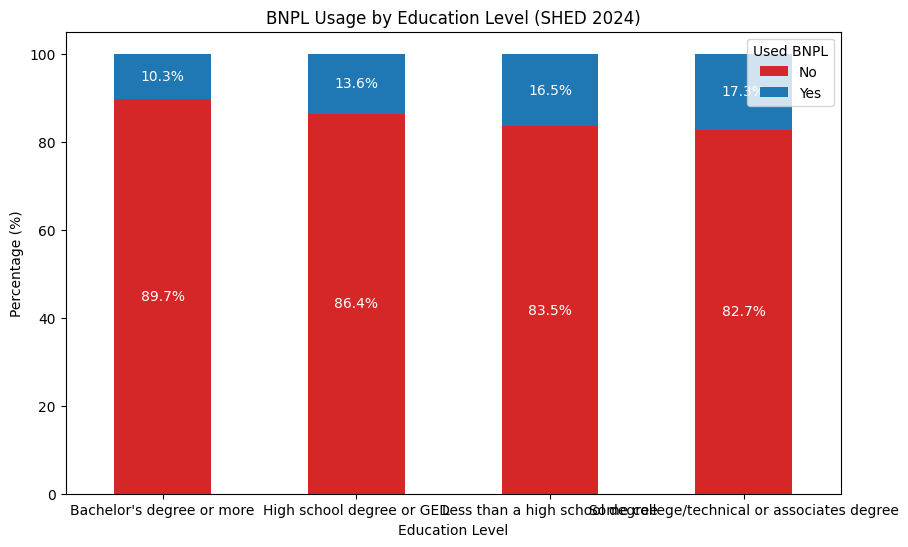

In [23]:
# calculate usage rates by education category

group = csv_df.groupby(['educ_4cat','BNPL1']).size().unstack(fill_value=0)
# compute percentages within each education
grp_pct = group.div(group.sum(axis=1), axis=0) * 100

print(group)
print(grp_pct)

grp_pct.plot(kind='bar', stacked=True, figsize=(10,6), color=['#d62728','#1f77b4'])
plt.title('BNPL Usage by Education Level (SHED 2024)')
plt.ylabel('Percentage (%)')
plt.xlabel('Education Level')
plt.xticks(rotation=0)
plt.legend(title='Used BNPL', loc='upper right')

# add labels
for i, edu in enumerate(grp_pct.index):
    for j, val in enumerate(grp_pct.loc[edu]):
        plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,
                 f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.show()


In [10]:
# Explore A1_a and BNPL_1 variables
print("=== Exploring A1_a (Credit Denial in Past 12 Months) ===")
if 'A1_a' in csv_df.columns:
    print(f"A1_a value counts:")
    print(csv_df['A1_a'].value_counts(dropna=False))
    print(f"\nA1_a data type: {csv_df['A1_a'].dtype}")
else:
    print("A1_a column not found. Checking for similar columns...")
    a1_cols = [c for c in csv_df.columns if 'A1' in c]
    print(f"A1-related columns: {a1_cols}")

print("\n=== Exploring BNPL_1 (or BNPL1) ===")
if 'BNPL_1' in csv_df.columns:
    print(f"BNPL_1 value counts:")
    print(csv_df['BNPL_1'].value_counts(dropna=False))
elif 'BNPL1' in csv_df.columns:
    print(f"BNPL1 value counts:")
    print(csv_df['BNPL1'].value_counts(dropna=False))
else:
    print("BNPL_1 or BNPL1 column not found. Checking for similar columns...")
    bnpl_cols = [c for c in csv_df.columns if 'BNPL' in c]
    print(f"BNPL-related columns: {bnpl_cols}")

=== Exploring A1_a (Credit Denial in Past 12 Months) ===
A1_a value counts:
A1_a
NaN    8184
No     3110
Yes    1001
Name: count, dtype: int64

A1_a data type: str

=== Exploring BNPL_1 (or BNPL1) ===
BNPL1 value counts:
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64


In [11]:
# Create analysis: BNPL users and credit denial in past 12 months
# Filter to BNPL1 = Yes and drop NaN values in A1_a

df_bnpl_analysis = csv_df[['A1_a', 'BNPL1']].copy()

# First, look at all data cross-tabulation
print("=== Cross-tabulation: A1_a vs BNPL1 (All Data) ===")
crosstab_all = pd.crosstab(df_bnpl_analysis['A1_a'], df_bnpl_analysis['BNPL1'], margins=True)
print(crosstab_all)

# Now filter to BNPL users only
bnpl_users_df = df_bnpl_analysis[df_bnpl_analysis['BNPL1'] == 'Yes'].copy()
bnpl_users_df = bnpl_users_df[bnpl_users_df['A1_a'].notna()]

print(f"\n=== BNPL Users with A1_a Response ===")
print(f"Total BNPL users with credit denial answer: {len(bnpl_users_df)}")

credit_denial_among_bnpl = bnpl_users_df['A1_a'].value_counts()
print("\nCredit Denial in Past 12 Months Among BNPL Users:")
print(credit_denial_among_bnpl)

# Calculate percentages
print("\nPercentages:")
for status, count in credit_denial_among_bnpl.items():
    pct = (count / len(bnpl_users_df)) * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

# Create tidy dataframe for Tableau
tidy_bnpl_a1 = []
for denial_status in ['No', 'Yes']:
    count = len(bnpl_users_df[bnpl_users_df['A1_a'] == denial_status])
    pct = (count / len(bnpl_users_df) * 100) if len(bnpl_users_df) > 0 else 0
    
    tidy_bnpl_a1.append({
        'BNPL_User': 'Yes',
        'Denied_Credit_Past_12M': denial_status,
        'Count': count,
        'Percentage': round(pct, 2)
    })

tidy_df = pd.DataFrame(tidy_bnpl_a1)
print("\n=== Tidy Data for Tableau ===")
print(tidy_df)

# Save to CSV
tidy_df.to_csv('bnpl_users_credit_denial_12months.csv', index=False)
print("\nExported to: bnpl_users_credit_denial_12months.csv")

=== Cross-tabulation: A1_a vs BNPL1 (All Data) ===
BNPL1    No  Yes   All
A1_a                  
No     2600  510  3110
Yes     576  425  1001
All    3176  935  4111

=== BNPL Users with A1_a Response ===
Total BNPL users with credit denial answer: 935

Credit Denial in Past 12 Months Among BNPL Users:
A1_a
No     510
Yes    425
Name: count, dtype: int64

Percentages:
  No: 510 (54.5%)
  Yes: 425 (45.5%)

=== Tidy Data for Tableau ===
  BNPL_User Denied_Credit_Past_12M  Count  Percentage
0       Yes                     No    510       54.55
1       Yes                    Yes    425       45.45

Exported to: bnpl_users_credit_denial_12months.csv


Visualization saved to: bnpl_users_credit_denial_12months.png


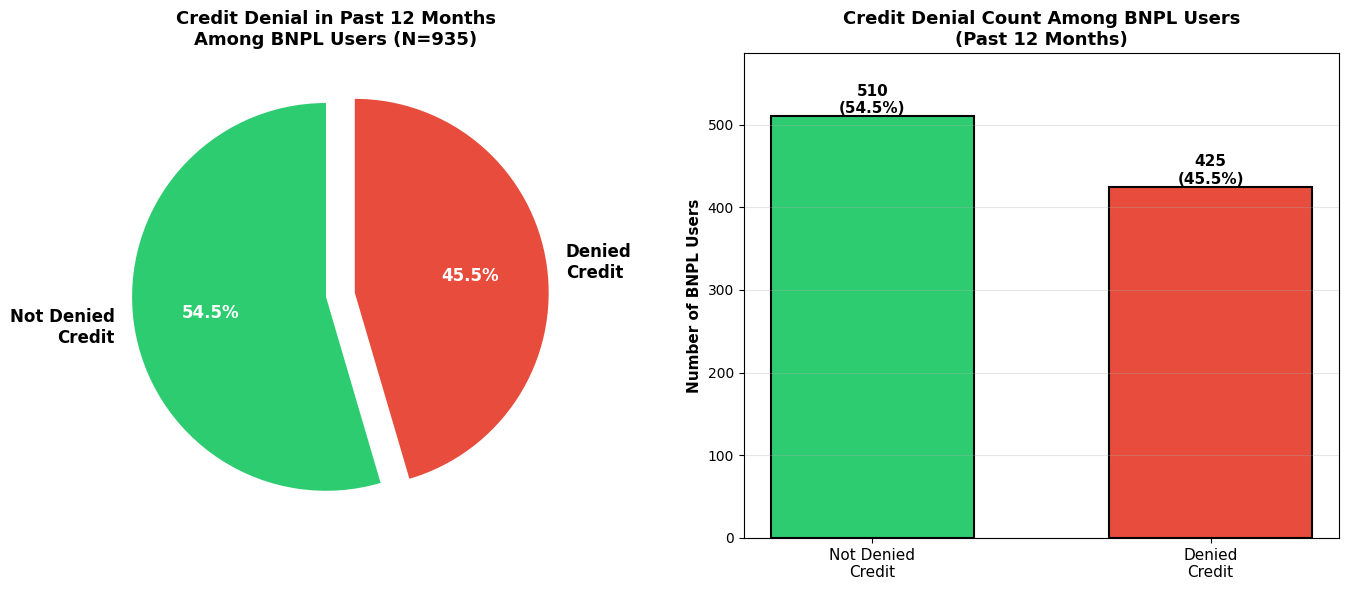


KEY FINDING: BNPL Usage vs Credit Denial (Past 12 Months)

Among 935 BNPL users surveyed:

  ✓ NOT denied credit: 510 users (54.5%)
  ✗ DENIED credit:   425 users (45.5%)

Almost HALF of BNPL users reported being denied credit
in the past 12 months, suggesting BNPL may serve as an
alternative for credit-constrained consumers.


In [12]:
# Create visualization for BNPL users and credit denial
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data
denial_counts = credit_denial_among_bnpl
denial_labels = ['Not Denied\nCredit', 'Denied\nCredit']
denial_values = [denial_counts['No'], denial_counts['Yes']]

# Chart 1: Pie chart
ax1 = axes[0]
colors = ['#2ecc71', '#e74c3c']  # green for not denied, red for denied
explode = (0.05, 0.1)

wedges, texts, autotexts = ax1.pie(denial_values, 
                                     labels=denial_labels,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})

ax1.set_title(f'Credit Denial in Past 12 Months\nAmong BNPL Users (N={len(bnpl_users_df)})', 
             fontweight='bold', fontsize=13)

# Make percentage text white for better visibility
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

# Chart 2: Bar chart with counts
ax2 = axes[1]
x_pos = np.arange(len(denial_labels))
bars = ax2.bar(x_pos, denial_values, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

ax2.set_ylabel('Number of BNPL Users', fontweight='bold', fontsize=11)
ax2.set_title('Credit Denial Count Among BNPL Users\n(Past 12 Months)', fontweight='bold', fontsize=13)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(denial_labels, fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(denial_values) * 1.15)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(bnpl_users_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('bnpl_users_credit_denial_12months.png', dpi=150, bbox_inches='tight')
print("Visualization saved to: bnpl_users_credit_denial_12months.png")
plt.show()

print("\n" + "="*60)
print("KEY FINDING: BNPL Usage vs Credit Denial (Past 12 Months)")
print("="*60)
print(f"\nAmong {len(bnpl_users_df)} BNPL users surveyed:")
print(f"\n  ✓ NOT denied credit: {denial_counts['No']} users (54.5%)")
print(f"  ✗ DENIED credit:   {denial_counts['Yes']} users (45.5%)")
print(f"\nAlmost HALF of BNPL users reported being denied credit")
print(f"in the past 12 months, suggesting BNPL may serve as an")
print(f"alternative for credit-constrained consumers.")
print("="*60)

In [13]:
# Analyze non-BNPL users and credit denial in past 12 months

# Filter to non-BNPL users (BNPL1 = No)
non_bnpl_users_df = df_bnpl_analysis[df_bnpl_analysis['BNPL1'] == 'No'].copy()
non_bnpl_users_df = non_bnpl_users_df[non_bnpl_users_df['A1_a'].notna()]

print("\n" + "="*60)
print("ANALYZING NON-BNPL USERS")
print("="*60)
print(f"\nTotal non-BNPL users with credit denial answer: {len(non_bnpl_users_df)}")

credit_denial_non_bnpl = non_bnpl_users_df['A1_a'].value_counts()
print("\nCredit Denial in Past 12 Months Among Non-BNPL Users:")
print(credit_denial_non_bnpl)

# Calculate percentages
print("\nPercentages:")
for status, count in credit_denial_non_bnpl.items():
    pct = (count / len(non_bnpl_users_df)) * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

# Create combined tidy dataframe for both BNPL and non-BNPL users
combined_data = []

# Add BNPL users
for denial_status in ['No', 'Yes']:
    count = len(bnpl_users_df[bnpl_users_df['A1_a'] == denial_status])
    pct = (count / len(bnpl_users_df) * 100) if len(bnpl_users_df) > 0 else 0
    
    combined_data.append({
        'BNPL_User': 'Yes',
        'Denied_Credit_Past_12M': denial_status,
        'Count': count,
        'Percentage': round(pct, 2)
    })

# Add non-BNPL users
for denial_status in ['No', 'Yes']:
    count = len(non_bnpl_users_df[non_bnpl_users_df['A1_a'] == denial_status])
    pct = (count / len(non_bnpl_users_df) * 100) if len(non_bnpl_users_df) > 0 else 0
    
    combined_data.append({
        'BNPL_User': 'No',
        'Denied_Credit_Past_12M': denial_status,
        'Count': count,
        'Percentage': round(pct, 2)
    })

combined_df = pd.DataFrame(combined_data)
print("\n=== Combined Tidy Data: BNPL Users vs Non-BNPL Users ===")
print(combined_df)

# Save to CSV
combined_df.to_csv('bnpl_credit_denial_comparison_12months.csv', index=False)
print("\nExported to: bnpl_credit_denial_comparison_12months.csv")

# Print comparison summary
print("\n" + "="*60)
print("COMPARISON: BNPL Users vs Non-BNPL Users")
print("="*60)
print(f"\nBNPL Users (N={len(bnpl_users_df)}):")
print(f"  Not denied: {credit_denial_among_bnpl['No']} (54.5%)")
print(f"  Denied:     {credit_denial_among_bnpl['Yes']} (45.5%)")

print(f"\nNon-BNPL Users (N={len(non_bnpl_users_df)}):")
print(f"  Not denied: {credit_denial_non_bnpl['No']} ({credit_denial_non_bnpl['No']/len(non_bnpl_users_df)*100:.1f}%)")
print(f"  Denied:     {credit_denial_non_bnpl['Yes']} ({credit_denial_non_bnpl['Yes']/len(non_bnpl_users_df)*100:.1f}%)")

denial_rate_bnpl = credit_denial_among_bnpl['Yes'] / len(bnpl_users_df) * 100
denial_rate_non_bnpl = credit_denial_non_bnpl['Yes'] / len(non_bnpl_users_df) * 100
print(f"\nDenial Rate Comparison:")
print(f"  BNPL users denied: {denial_rate_bnpl:.1f}%")
print(f"  Non-BNPL users denied: {denial_rate_non_bnpl:.1f}%")
print(f"  Difference: {denial_rate_bnpl - denial_rate_non_bnpl:.1f} percentage points")
print("="*60)


ANALYZING NON-BNPL USERS

Total non-BNPL users with credit denial answer: 3176

Credit Denial in Past 12 Months Among Non-BNPL Users:
A1_a
No     2600
Yes     576
Name: count, dtype: int64

Percentages:
  No: 2600 (81.9%)
  Yes: 576 (18.1%)

=== Combined Tidy Data: BNPL Users vs Non-BNPL Users ===
  BNPL_User Denied_Credit_Past_12M  Count  Percentage
0       Yes                     No    510       54.55
1       Yes                    Yes    425       45.45
2        No                     No   2600       81.86
3        No                    Yes    576       18.14

Exported to: bnpl_credit_denial_comparison_12months.csv

COMPARISON: BNPL Users vs Non-BNPL Users

BNPL Users (N=935):
  Not denied: 510 (54.5%)
  Denied:     425 (45.5%)

Non-BNPL Users (N=3176):
  Not denied: 2600 (81.9%)
  Denied:     576 (18.1%)

Denial Rate Comparison:
  BNPL users denied: 45.5%
  Non-BNPL users denied: 18.1%
  Difference: 27.3 percentage points


Visualization saved to: bnpl_vs_nonbnpl_credit_denial_comparison.png


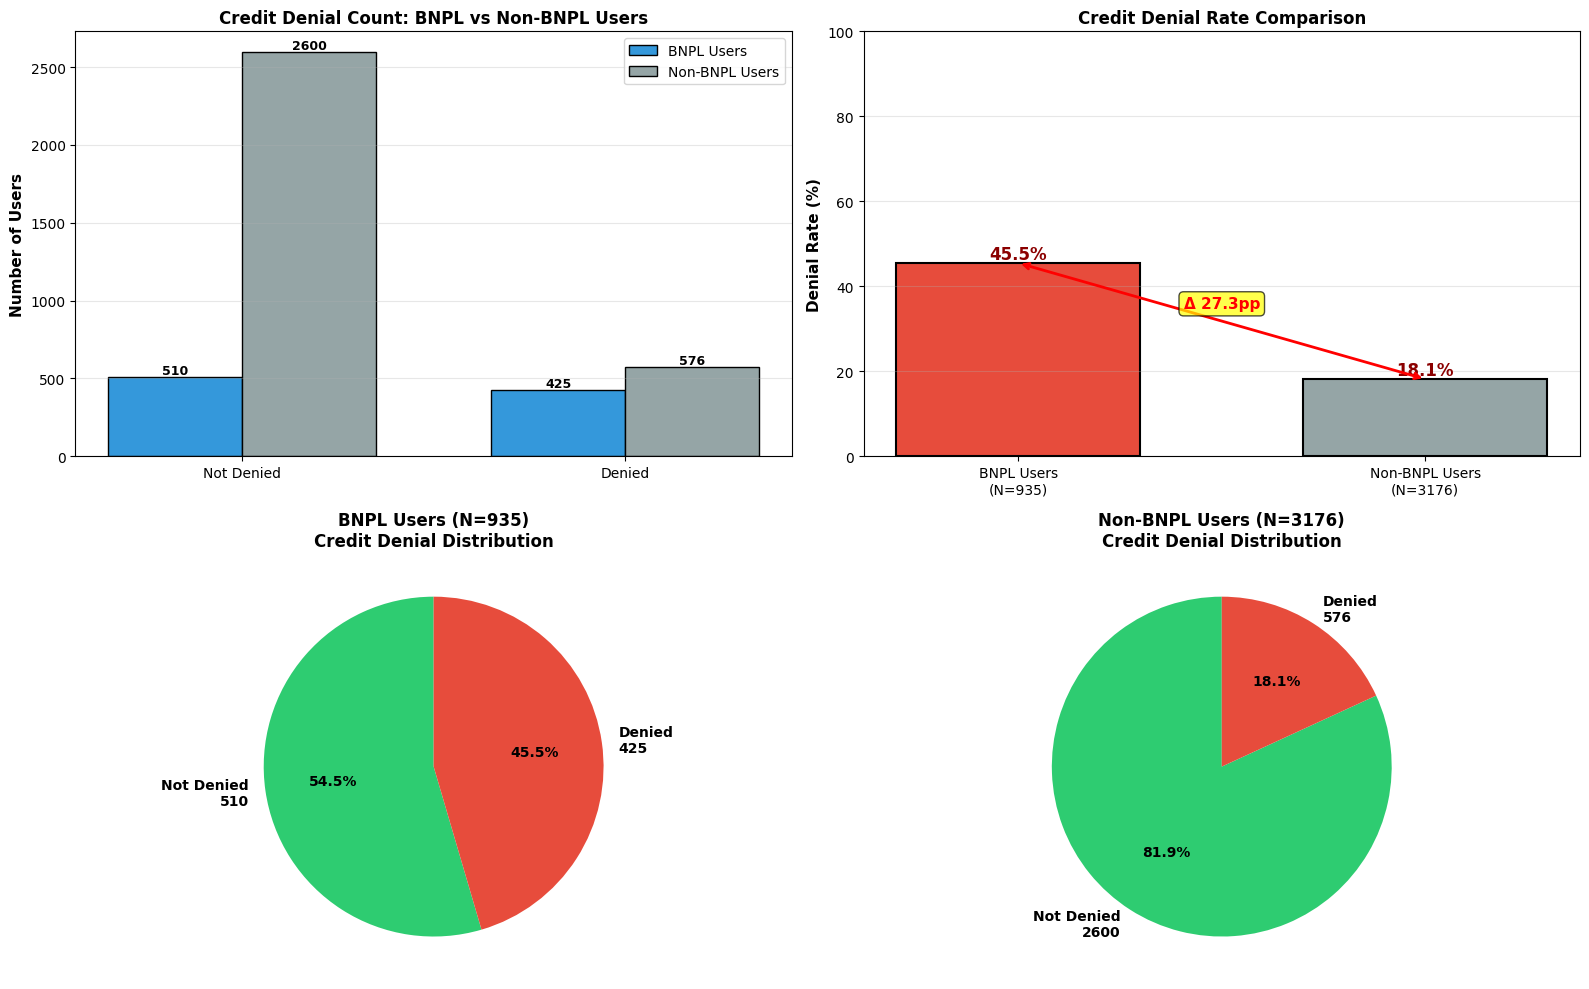


KEY FINDINGS: BNPL Users Are More Credit-Constrained

🔴 BNPL Users show MUCH HIGHER denial rates:
   • 45.5% of BNPL users were DENIED credit in past 12 months
   • Only 18.1% of Non-BNPL users were denied credit
   • DIFFERENCE: 27.3 percentage points

💡 IMPLICATIONS:
   • BNPL users are 2.5x more likely to be denied credit
   • BNPL appears to serve credit-rationed consumers
   • Strong evidence that BNPL is a substitute for credit


In [14]:
# Create comparative visualization: BNPL vs Non-BNPL users
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Data preparation
bnpl_not_denied = len(bnpl_users_df[bnpl_users_df['A1_a'] == 'No'])
bnpl_denied = len(bnpl_users_df[bnpl_users_df['A1_a'] == 'Yes'])
non_bnpl_not_denied = len(non_bnpl_users_df[non_bnpl_users_df['A1_a'] == 'No'])
non_bnpl_denied = len(non_bnpl_users_df[non_bnpl_users_df['A1_a'] == 'Yes'])

# Percentages
bnpl_denial_pct = bnpl_denied / len(bnpl_users_df) * 100
non_bnpl_denial_pct = non_bnpl_denied / len(non_bnpl_users_df) * 100

# Chart 1: Grouped bar chart comparing absolute counts
ax1 = axes[0, 0]
categories = ['Not Denied', 'Denied']
bnpl_counts = [bnpl_not_denied, bnpl_denied]
non_bnpl_counts = [non_bnpl_not_denied, non_bnpl_denied]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, bnpl_counts, width, label='BNPL Users', color='#3498db', edgecolor='black', linewidth=1)
bars2 = ax1.bar(x + width/2, non_bnpl_counts, width, label='Non-BNPL Users', color='#95a5a6', edgecolor='black', linewidth=1)

ax1.set_ylabel('Number of Users', fontweight='bold', fontsize=11)
ax1.set_title('Credit Denial Count: BNPL vs Non-BNPL Users', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2: Denial rate comparison (side-by-side bars)
ax2 = axes[0, 1]
denial_rates = [bnpl_denial_pct, non_bnpl_denial_pct]
groups = ['BNPL Users\n(N=935)', 'Non-BNPL Users\n(N=3176)']
colors_rate = ['#e74c3c', '#95a5a6']

bars = ax2.bar(groups, denial_rates, color=colors_rate, edgecolor='black', linewidth=1.5, width=0.6)
ax2.set_ylabel('Denial Rate (%)', fontweight='bold', fontsize=11)
ax2.set_title('Credit Denial Rate Comparison', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, rate in zip(bars, denial_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

# Add difference annotation
ax2.annotate('', xy=(0, bnpl_denial_pct), xytext=(1, non_bnpl_denial_pct),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(0.5, (bnpl_denial_pct + non_bnpl_denial_pct) / 2 + 3, 
        f'Δ {bnpl_denial_pct - non_bnpl_denial_pct:.1f}pp',
        ha='center', fontsize=11, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Chart 3: BNPL Users - Pie chart
ax3 = axes[1, 0]
bnpl_pie_data = [bnpl_not_denied, bnpl_denied]
bnpl_labels = [f'Not Denied\n{bnpl_not_denied}', f'Denied\n{bnpl_denied}']
colors_bnpl = ['#2ecc71', '#e74c3c']

ax3.pie(bnpl_pie_data, labels=bnpl_labels, autopct='%1.1f%%', colors=colors_bnpl,
       startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax3.set_title(f'BNPL Users (N={len(bnpl_users_df)})\nCredit Denial Distribution', 
             fontweight='bold', fontsize=12)

# Chart 4: Non-BNPL Users - Pie chart
ax4 = axes[1, 1]
non_bnpl_pie_data = [non_bnpl_not_denied, non_bnpl_denied]
non_bnpl_labels = [f'Not Denied\n{non_bnpl_not_denied}', f'Denied\n{non_bnpl_denied}']
colors_non_bnpl = ['#2ecc71', '#e74c3c']

ax4.pie(non_bnpl_pie_data, labels=non_bnpl_labels, autopct='%1.1f%%', colors=colors_non_bnpl,
       startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title(f'Non-BNPL Users (N={len(non_bnpl_users_df)})\nCredit Denial Distribution', 
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('bnpl_vs_nonbnpl_credit_denial_comparison.png', dpi=150, bbox_inches='tight')
print("Visualization saved to: bnpl_vs_nonbnpl_credit_denial_comparison.png")
plt.show()

print("\n" + "="*70)
print("KEY FINDINGS: BNPL Users Are More Credit-Constrained")
print("="*70)
print(f"\n🔴 BNPL Users show MUCH HIGHER denial rates:")
print(f"   • 45.5% of BNPL users were DENIED credit in past 12 months")
print(f"   • Only 18.1% of Non-BNPL users were denied credit")
print(f"   • DIFFERENCE: {bnpl_denial_pct - non_bnpl_denial_pct:.1f} percentage points")
print(f"\n💡 IMPLICATIONS:")
print(f"   • BNPL users are 2.5x more likely to be denied credit")
print(f"   • BNPL appears to serve credit-rationed consumers")
print(f"   • Strong evidence that BNPL is a substitute for credit")
print("="*70)